# Graph of Marks (GoM) - Comprehensive Demo



This notebook demonstrates the full functionality of the Graph of Marks (GoM) library.
We will cover:
1.  **Baseline VQA**: Running a VQA model (Gemma3-4b via Ollama) on a raw image.
2.  **GoM Walkthrough**: Step-by-step application of the GoM pipeline (Detection, Segmentation, Relations, Graph).
3.  **Hyperparameter Tuning**: Visualizing the effect of different parameters.
4.  **GoM-Enhanced VQA**: Running the VQA model on the GoM-processed image.



## 1. Setup and Data Loading


Loaded data:
   id                     path  \
0   0  images/vqav2_sample.png   
1   1    images/gqa_sample.jpg   

                                            question  
0                Is the potted plant below the oven?  
1  Is the bowl in the top part or in the bottom o...  

Selected Image: ../images/vqav2_sample.png
Question: Is the potted plant below the oven?


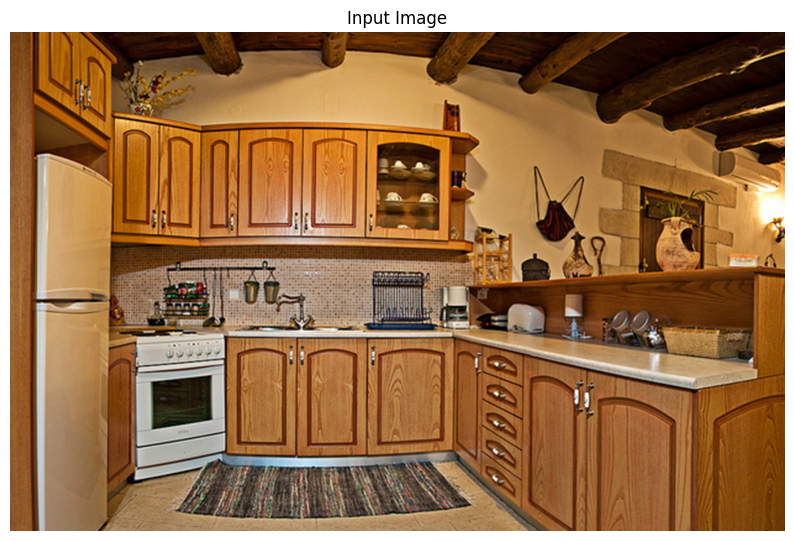

In [1]:

import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torch
import numpy as np

# Ensure we are in the project root or adjust paths
if os.path.exists("images/example_data.csv"):
    DATA_PATH = "images/example_data.csv"
    IMAGE_DIR = "images"
else:
    # Fallback if running from examples/
    DATA_PATH = "../images/example_data.csv"
    IMAGE_DIR = "../images"

# Load data
df = pd.read_csv(DATA_PATH)
print("Loaded data:")
print(df.head())

# Select the first example
row = df.iloc[0]
image_path = os.path.join(IMAGE_DIR, os.path.basename(row['path']))
question = row['question']

print(f"\nSelected Image: {image_path}")
print(f"Question: {question}")

# Display image
image = Image.open(image_path).convert("RGB")
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')
plt.title("Input Image")
plt.show()



## 2. Baseline VQA (Gemma3-4b via Ollama)


We first run a baseline VQA query using `gemma3:4b` (via Ollama) on the raw image without any preprocessing.


In [2]:
import ollama

# Function to run VQA via Ollama
def run_ollama_vqa(image_path, question, model="gemma3:4b"):
    try:
        print(f"Running {model} on {image_path}...")
        # Note: Ollama python client usage might vary based on version.
        # Assuming standard chat or generate API with image support.
        response = ollama.chat(
            model=model,
            messages=[
                {
                    'role': 'user',
                    'content': question,
                    'images': [image_path]
                }
            ]
        )
        return response['message']['content']
    except Exception as e:
        return f"Error running Ollama: {e}"

# Run baseline
baseline_answer = run_ollama_vqa(image_path, question)
print(f"\nQuestion: {question}")
print(f"Baseline Answer: {baseline_answer}")



Running gemma3:4b on ../images/vqav2_sample.png...

Question: Is the potted plant below the oven?
Baseline Answer: Yes, in the image, the potted plant is located directly below the oven.


## 3. Graph of Marks (GoM) Pipeline - Step by Step


Now we introduce the GoM library and apply its default functions step by step to preprocess the image. We will show intermediate results for each stage.


In [ ]:

from gom import GraphOfMarks
from gom.pipeline.preprocessor import ImageGraphPreprocessor
from gom.config import PreprocessorConfig

# Initialize with default configuration
# We use the lower-level ImageGraphPreprocessor for step-by-step control
# Note: You can specify the path to your SAM checkpoint using 'sam_checkpoint_path'.
# Configuration Parameters
# You can adjust these parameters to customize the pipeline
DETECTORS = ["yolov8", "owlvit"]   # Detectors to use
SAM_VERSION = "2"                  # SAM variant: "1", "2", or "hq"
SAM_CHECKPOINT = "../checkpoints/sam2.1_hiera_tiny.pt" # Path to checkpoint
ENABLE_DEPTH = True                # Enable 3D spatial reasoning
DEVICE = "cpu"                     # Device: "cpu", "cuda", or "mps"

# Initialize Configuration
config = PreprocessorConfig(
    detectors_to_use=DETECTORS,
    sam_version=SAM_VERSION,
    segmenter_kwargs={"checkpoint": SAM_CHECKPOINT}, # Pass checkpoint via kwargs
    enable_spatial_3d=ENABLE_DEPTH,
    output_folder="demo_output",
    preproc_device=DEVICE
)

preprocessor = ImageGraphPreprocessor(config)
print(f"GoM Preprocessor initialized on device: {preprocessor.device}")
for i, det in enumerate(preprocessor.detectors):
    print(f"Detector {i} ({det.name}) device: {det.device}")



Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!


YOLOv8x summary (fused): 112 layers, 68,200,608 parameters, 0 gradients, 257.8 GFLOPs
[RelationInferencer] Spatial3DReasoner activated
[RelationInferencer] PhysicsReasoner activated
GoM Preprocessor initialized on device: cpu
Detector 0 (owlvit) device: cpu
Detector 1 (yolov8) device: cpu


### Step 3.1: Object Detection


We detect objects using the configured detectors (YOLOv8 + OWL-ViT) and fuse the results.


Detected 56 objects.
Step 1: Object Detection


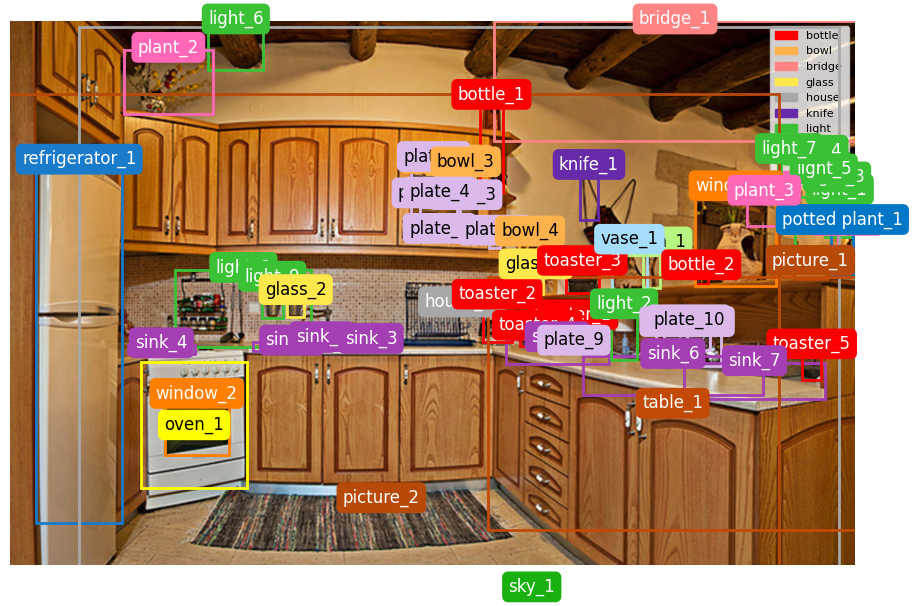

In [4]:

# 1. Detect Objects
# Accessing the internal detector manager
# Note: In a production script, you might use process_single_image, but here we want to show steps.

# We need to manually trigger detection.
# The detector manager expects a list of images and returns a list of lists of detections.
detections = preprocessor.detector_manager.detect_ensemble([image], fuse=True)[0]

print(f"Detected {len(detections)} objects.")

# Visualize Detections
from gom.viz.visualizer import Visualizer, VisualizerConfig
# Visualize Detections
from gom.viz.visualizer import Visualizer, VisualizerConfig
viz = Visualizer(VisualizerConfig(show_segmentation=False, display_relationships=False))

# Extract data for visualizer
boxes = [d.box for d in detections]
labels = [d.label for d in detections]
scores = [d.score for d in detections]

# Draw detections
# viz.draw returns (fig, ax) and calls plt.show() by default
print("Step 1: Object Detection")
_ = viz.draw(image, boxes, labels, scores, relationships=[])



### Step 3.2: Instance Segmentation


We generate segmentation masks for the detected boxes using SAM.


Generated 56 masks.
Step 2: Instance Segmentation


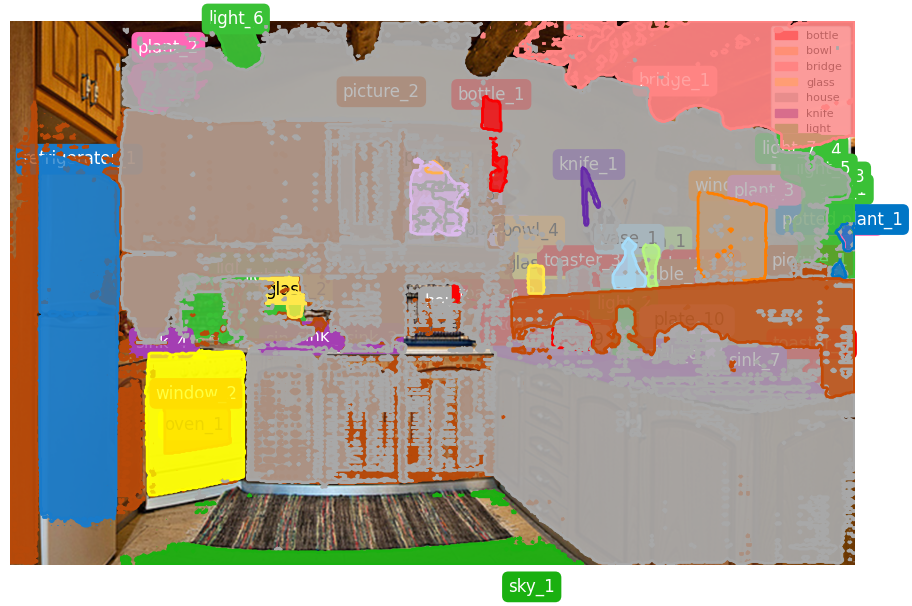

In [5]:

# 2. Segment Objects
# We extract boxes from detections
boxes = [d.box for d in detections]

# Run segmentation
# The segmenter expects boxes in XYXY format
masks = preprocessor.segmenter.segment(image, boxes)

print(f"Generated {len(masks)} masks.")

# Update detections with masks
for det, mask_dict in zip(detections, masks):
    det.mask = mask_dict['segmentation']

# Visualize Segmentation
viz_seg = Visualizer(VisualizerConfig(show_segmentation=True, display_relationships=False))

# Draw segmentation
print("Step 2: Instance Segmentation")
_ = viz_seg.draw(image, boxes, labels, scores, relationships=[], masks=masks)



### Step 3.3: Depth Estimation


We estimate the monocular depth map to help with 3D spatial reasoning.


[DEPTH] Loading Depth Anything V2 (vitl)...
[DEPTH] ✓ Using cached checkpoint: depth_anything_v2_vitl.pth
[DEPTH] ✓ Using installed depth_anything_v2 module
[DEPTH] Initializing Depth Anything V2 (vitl)...
[DEPTH] Loading weights...
[DEPTH] ✓ Depth Anything V2 (vitl) loaded successfully


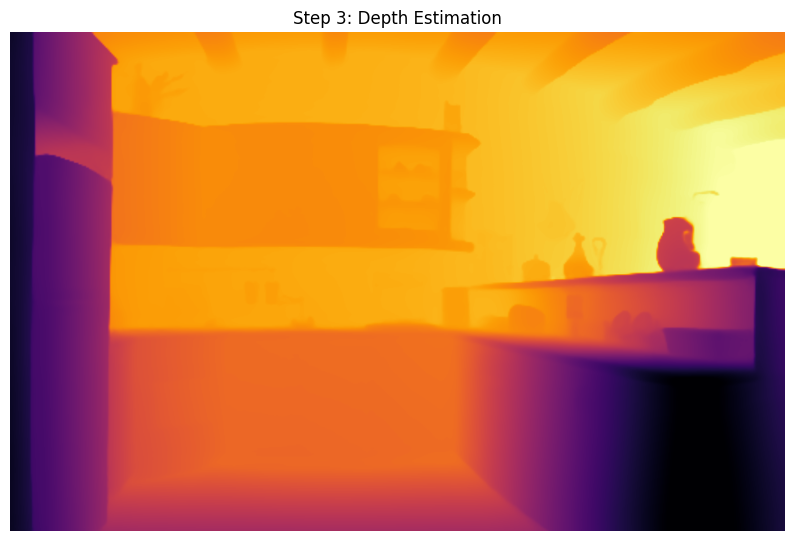

In [6]:
# 3. Estimate Depth
depth_map = preprocessor.depth_est.infer_map(image)

plt.figure(figsize=(10, 10))
if depth_map is not None:
    plt.imshow(depth_map, cmap='inferno')
    plt.title("Step 3: Depth Estimation")
else:
    plt.text(0.5, 0.5, "Depth Estimation Unavailable", ha='center', va='center')
    plt.title("Step 3: Depth Estimation (Failed)")
plt.axis('off')
plt.show()



### Step 3.4: Relationship Extraction


We extract spatial and semantic relationships between objects.


In [ ]:

# 4. Extract Relations
# We need to pass boxes, labels, image, and depth map
relations = preprocessor.relations_inferencer.infer(
    image_pil=image,
    boxes=boxes,
    labels=labels,
    depth_map=depth_map,
    masks=masks
)

print(f"Extracted {len(relations)} relationships.")

# Visualize Relations
viz_rel = Visualizer(VisualizerConfig(
    show_segmentation=True, 
    display_relationships=True,
    display_relation_labels=True
))

# Draw full scene graph
print("Step 4: Full Scene Graph (Relations)")
# Save directly to file for next steps
output_path = "demo_output/gom_processed.jpg"
viz_rel.draw(image, boxes, labels, scores, relationships=relations, masks=masks, save_path=output_path)

# Display the saved image
plt.figure(figsize=(12, 12))
plt.imshow(Image.open(output_path))
plt.axis('off')
plt.title("Step 4: Full Scene Graph (Relations)")
plt.show()



## 4. Hyperparameter Exploration


We can graphically explore how changing hyperparameters affects the output.


In [ ]:

import ipywidgets as widgets
from IPython.display import display

def update_viz(conf_threshold, show_masks, show_relations):
    # Filter detections by confidence and track indices
    keep_indices = [i for i, d in enumerate(detections) if d.score >= conf_threshold]
    filtered_dets = [detections[i] for i in keep_indices]
    
    # Remap indices for relations
    idx_map = {old_idx: new_idx for new_idx, old_idx in enumerate(keep_indices)}
    
    filtered_rels = []
    for r in relations:
        s, t = r['src_idx'], r['tgt_idx']
        if s in idx_map and t in idx_map:
            new_r = r.copy()
            new_r['src_idx'] = idx_map[s]
            new_r['tgt_idx'] = idx_map[t]
            filtered_rels.append(new_r)
            
    filtered_masks = [masks[i] for i in keep_indices] if masks else None
    
    # Update config for visualization
    cfg = VisualizerConfig(
        show_segmentation=show_masks,
        display_relationships=show_relations,
        display_labels=True
    )
    v = Visualizer(cfg)
    
    # Extract data for visualizer
    boxes = [d.box for d in filtered_dets]
    labels = [d.label for d in filtered_dets]
    scores = [d.score for d in filtered_dets]
    
    # Draw
    _ = v.draw(image, boxes, labels, scores, relationships=filtered_rels, masks=filtered_masks)

# Create widgets
w_conf = widgets.FloatSlider(value=0.3, min=0.0, max=1.0, step=0.05, description='Conf Thresh:')
w_masks = widgets.Checkbox(value=True, description='Show Masks')
w_rels = widgets.Checkbox(value=True, description='Show Relations')

ui = widgets.HBox([w_conf, w_masks, w_rels])
out = widgets.interactive_output(update_viz, {'conf_threshold': w_conf, 'show_masks': w_masks, 'show_relations': w_rels})

display(ui, out)



## 5. GoM-Enhanced VQA


Now we run the VQA model again, but this time using the GoM-preprocessed image (Graph of Marks).


In [ ]:

# The processed image was saved in Step 4
output_path = "demo_output/gom_processed.jpg"
# Image.fromarray(final_viz).save(output_path) # Already saved

# Run VQA on the processed image
gom_answer = run_ollama_vqa(output_path, question)

print(f"\nQuestion: {question}")
print(f"Baseline Answer: {baseline_answer}")
print(f"GoM Answer:      {gom_answer}")

